In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
incident_path = r'C:\Users\dcheruiyot2\OneDrive - KPMG\Projects\it-incident-forecasting\data\incident.xlsx'
time_card_path = r'C:\Users\dcheruiyot2\OneDrive - KPMG\Projects\it-incident-forecasting\data\time_card_daily.xlsx'

In [3]:
def load_data(path):
    sheets = pd.read_excel(path, sheet_name=None)
    frames = []
    for name, df in sheets.items():
        df = df.copy()
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

incidents = load_data(incident_path)
time_cards = load_data(time_card_path)

In [4]:
incidents.columns = incidents.columns.str.lower().str.replace(" ", "_")

incidents.head()

,number,opened,closed,company,short_description,priority,category,assignment_group,assigned_to,business_service
0,INC0031376,2025-04-11 14:16:44,2025-05-08 11:00:00,Network Rail,API Update - field duplication,3 - Moderate,Change Request,Power Platform Network Rail Support,Mannan Aftab,Network Rail Microsoft Platform Support
1,INC0029955,2024-12-05 12:47:46,2025-01-17 13:00:02,Network Rail,Actual Days Lost showing incorrectly,4 - Low,Bug,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support
2,INC0029870,2024-12-02 17:58:49,2025-01-17 13:00:03,Network Rail,Related columns in Safety Events showing no data,4 - Low,Bug,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support
3,INC0032801,2025-11-03 14:06:03,2025-11-28 10:00:00,Leeds City Council,Approving stuck state,2 - High,Performance,Power Platform Leeds Agents,Vikranth B,Leeds Power Platform Support
4,INC0031948,2025-07-09 10:05:40,2025-09-27 12:00:00,Network Rail,Approved by DCP date on Investigations date de...,3 - Moderate,Bug,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support


In [5]:
time_cards.columns = time_cards.columns.str.lower().str.replace(" ", "_")
time_cards.head()

,date,number,short_description,company,business_service,project_id,technology,user,grade,specialisation,time_worked
0,2024-07-24,INC0028371,Commercial invoice for SH-000313421 cannot be ...,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Mario Gauci,C2,FO Functional,0.25
1,2024-05-09,GEN0010302,SDM / EM / EL,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Ivan Louis Carabott,B1,SDM,1.00
2,2024-06-06,INC0027508,SO-1000014382 - invoiced lines showing in menu...,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Jomer Majadas Sanosa,C1,FO Functional,1.00
3,2024-10-14,CHG0033079,Transition to Azure SynapseLink,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Jomer Majadas Sanosa,C1,FO Functional,1.50
4,2024-12-03,INC0029373,VOUS000186 - include selected voyage does not ...,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Kadali Santosh,D1,FO Functional,2.00


In [6]:
incidents_df = incidents.copy()


#### time cards initial EDA

In [7]:
print(f"Shape: {time_cards.shape}")
summary = pd.DataFrame({
    "dtypes":time_cards.dtypes,
    "nulls": time_cards.isnull().sum(),
    "nulls_pct": (time_cards.isnull().sum()/len(time_cards) * 100).round(1),
    "unique": time_cards.nunique()
})

summary



Shape: (87393, 11)


,dtypes,nulls,nulls_pct,unique
date,datetime64[ns],0,0.0,653
number,object,300,0.3,6975
short_description,object,300,0.3,6445
company,object,300,0.3,46
business_service,object,453,0.5,85
project_id,object,1574,1.8,53
technology,object,1574,1.8,9
user,object,0,0.0,158
grade,object,54,0.1,10
specialisation,object,13031,14.9,10


15% of Specialisation is missing data - Imputation??

300 rows Number, Short Description, Company seem to be missing, most likely same rows. Can be dropped

53 projects worked on, 46 Companies handled, 9 technologies, 85 Business Service



2024-05-01 00:00:00 2026-05-29 00:00:00


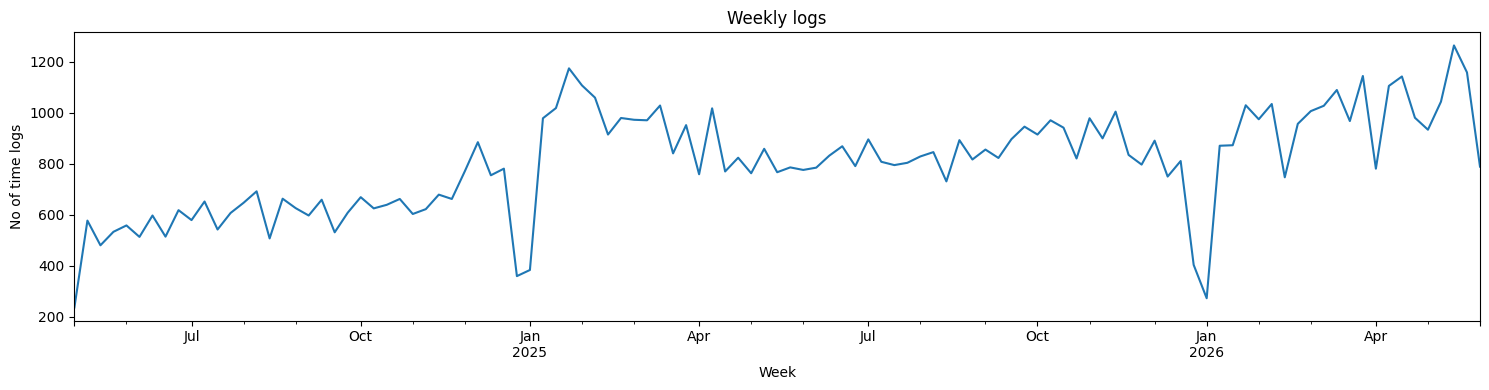

In [8]:
# date columns
max_date = time_cards['date'].max()
min_date = time_cards['date'].min()
print(min_date, max_date)
duration =(max_date - min_date).days

time_cards['week'] = time_cards['date'].dt.to_period("W")

time_cards.groupby("week").size().plot(figsize=(15,4))
plt.xlabel('Week')
plt.ylabel('No of time logs')
plt.title("Weekly logs")
plt.tight_layout()
plt.show()

Major dips in Dec - Jan season , maybe due to leave days taken.
Other minor dips Aug-Sept

count    87393.000000
mean         1.775295
std          1.731506
min         -8.000000
25%          0.500000
50%          1.000000
75%          2.000000
max         35.000000
Name: time_worked, dtype: float64


<Axes: xlabel='time_worked', ylabel='Count'>

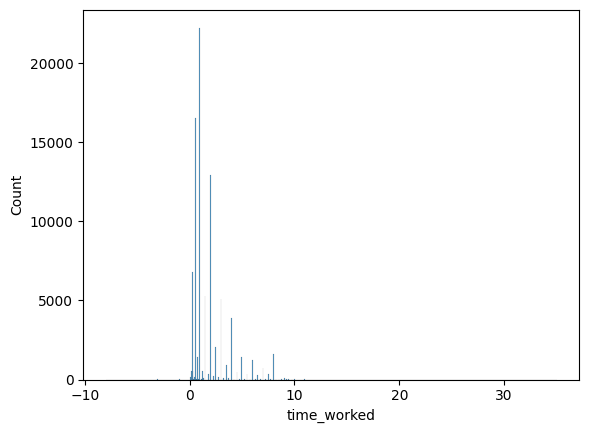

In [9]:
print(time_cards['time_worked'].describe())

sns.histplot(time_cards['time_worked'])

In [10]:
# implausible values - negative values, more than 10 hours
(time_cards['time_worked'] <= 0).sum(),  (time_cards['time_worked'] >= 10).sum()



(np.int64(46), np.int64(64))

46 entries with Negative time_worked. What does it mean when negative values are logged??? and 29 entries with time greater than 10 . Are there specific incidents that are logged as negative ie corrections/adjustments

In [41]:
time_cards[time_cards['time_worked'] > 10].value_counts()

date        number         short_description                                                          company                      business_service                         project_id         technology                      user                    grade  specialisation  time_worked  week                   cal_week  year
2024-06-11  GEN0010348     SDM / EM / EL                                                              ACCA                         ACCA FO Support                          MIG90150722.1.1    Dynamics 365 FO                 Sue Harrington          B2     SDM             11.00        2024-06-10/2024-06-16  24        2024    1
2024-06-12  GEN0010075     SDM / EM / EL                                                              Wesleyan Assurance Society   Wesleyan FO Support                      MIG90136641.1.1    Dynamics 365 FO                 Nicola Lynch            C2     SDM             11.00        2024-06-10/2024-06-16  24        2024    1
2024-08-13  GEN0010143     

<Axes: title={'center': 'Total hours by grade'}, ylabel='grade'>

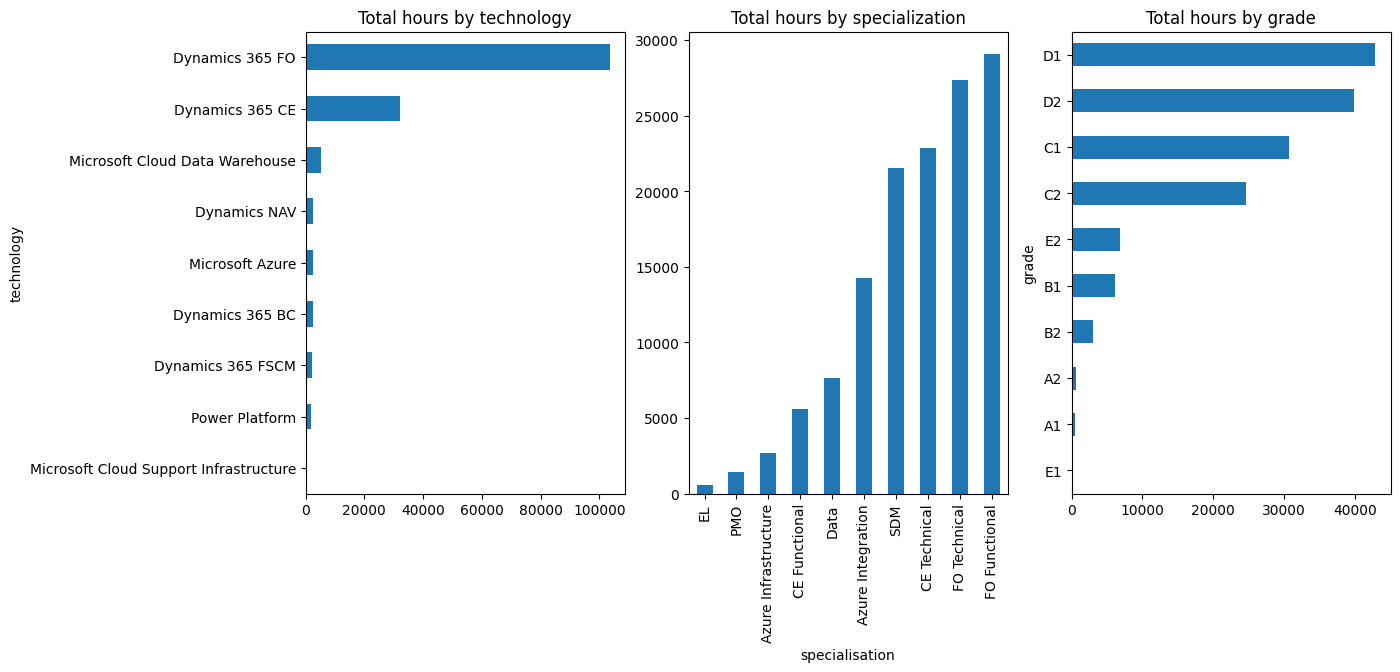

In [11]:
# effort by technonology, specialization snd grade
fig, axes = plt.subplots(1,3, figsize=(14,6))
time_cards.groupby('technology')['time_worked'].sum().sort_values(ascending=True).plot(kind='barh', ax=axes[0], title='Total hours by technology')
time_cards.groupby('specialisation')['time_worked'].sum().sort_values(ascending=True).plot(kind='bar', ax=axes[1], title='Total hours by specialization')
time_cards.groupby('grade')['time_worked'].sum().sort_values(ascending=True).plot(kind='barh', ax=axes[2], title='Total hours by grade')


In [12]:
#  hours logged weekly by year
time_cards['cal_week'] = time_cards['date'].dt.strftime('%W').astype(int)
time_cards['year'] = time_cards['date'].dt.year

weekly_hours_by_year = (time_cards.groupby(['year','cal_week'])['time_worked'].sum().unstack(level=0, fill_value=0).reindex(range(1,53), fill_value=0))
weekly_hours_by_year

year,2024,2025,2026
cal_week,,,
1,0.00,1758.75,1711.04
2,0.00,1713.48,1518.47
3,0.00,1980.25,1748.46
4,0.00,1908.66,1617.71
5,0.00,1842.50,1824.22
6,0.00,1662.10,1352.95
7,0.00,1849.41,1703.98
8,0.00,1837.91,1802.20
9,0.00,1918.75,1798.79


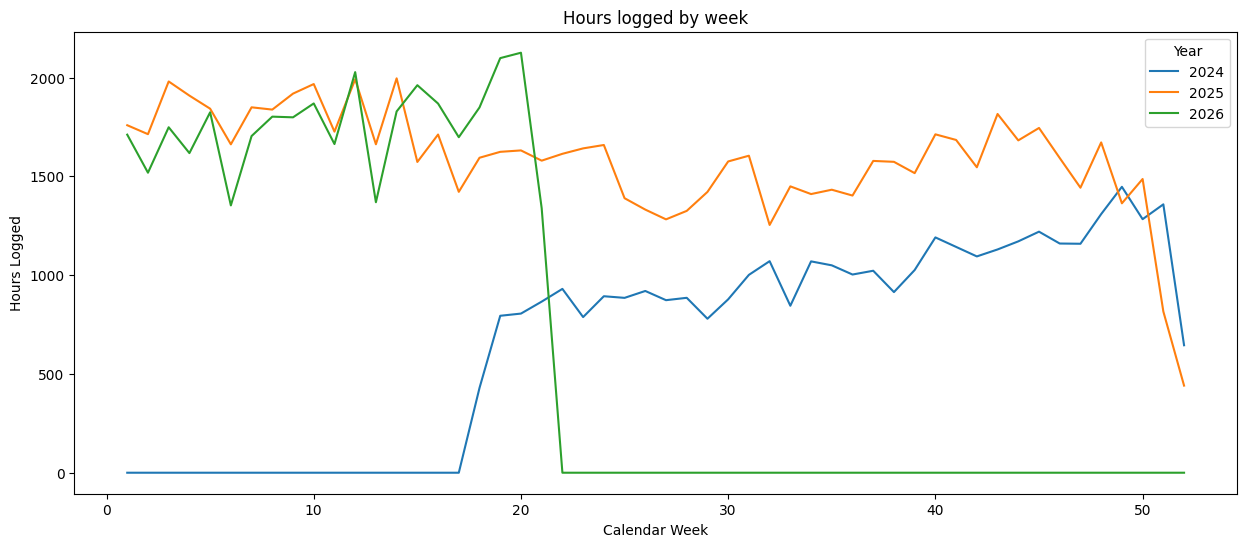

In [13]:
fig, ax = plt.subplots(figsize=(15,6))
for year in weekly_hours_by_year.columns:
    ax.plot(weekly_hours_by_year.index, weekly_hours_by_year[year], label=str(year))

ax.set_xlabel('Calendar Week')
ax.set_ylabel('Hours Logged')
ax.set_title('Hours logged by week')
ax.legend(title='Year')



Wk 6,11,17 obvious dips in 2025 and 2026

#### Incidents initial EDA

In [14]:
incidents.head()

,number,opened,closed,company,short_description,priority,category,assignment_group,assigned_to,business_service
0,INC0031376,2025-04-11 14:16:44,2025-05-08 11:00:00,Network Rail,API Update - field duplication,3 - Moderate,Change Request,Power Platform Network Rail Support,Mannan Aftab,Network Rail Microsoft Platform Support
1,INC0029955,2024-12-05 12:47:46,2025-01-17 13:00:02,Network Rail,Actual Days Lost showing incorrectly,4 - Low,Bug,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support
2,INC0029870,2024-12-02 17:58:49,2025-01-17 13:00:03,Network Rail,Related columns in Safety Events showing no data,4 - Low,Bug,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support
3,INC0032801,2025-11-03 14:06:03,2025-11-28 10:00:00,Leeds City Council,Approving stuck state,2 - High,Performance,Power Platform Leeds Agents,Vikranth B,Leeds Power Platform Support
4,INC0031948,2025-07-09 10:05:40,2025-09-27 12:00:00,Network Rail,Approved by DCP date on Investigations date de...,3 - Moderate,Bug,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support


In [15]:
print(f"Shape: {incidents.shape}")
summary = pd.DataFrame({
    "dtypes":incidents.dtypes,
    "nulls": incidents.isnull().sum(),
    "nulls_pct": (incidents.isnull().sum()/len(incidents) * 100).round(1),
    "unique": incidents.nunique()
})

summary



Shape: (5871, 10)


,dtypes,nulls,nulls_pct,unique
number,object,0,0.0,5871
opened,datetime64[ns],0,0.0,5858
closed,datetime64[ns],421,7.2,4339
company,object,0,0.0,37
short_description,object,0,0.0,5542
priority,object,0,0.0,4
category,object,261,4.4,14
assignment_group,object,18,0.3,55
assigned_to,object,22,0.4,184
business_service,object,29,0.5,74


7% of dataset don't have closed dates. Are these considered open or its a system error

4.4% has no category. How to handle this? Imputation?? 14 unique categories



In [47]:
# incidents still open
incidents[incidents['closed'].isnull()].sort_values(by='opened')

,number,opened,closed,company,short_description,priority,category,assignment_group,assigned_to,business_service,cal_week,year
2654,INC0027375,2024-05-08 14:21:24,NaT,KPMG Test Company,Test,4 - Low,NaN,NaN,Paul Caruana,TEST Finance Support,19,2024
5419,INC0028362,2024-07-16 17:09:38,NaT,Restore,Deleted purchase orders in Live should be run ...,4 - Low,NaN,BC Restore Agents,Widad ElAsly,Restore BC Support,29,2024
1522,INC0028363,2024-07-16 17:39:30,NaT,BCP Council,Leave balances screen taking long time to load,4 - Low,Performance,FO BCP Agents,Chinedu Augustine Muoneke,BCP FO Support,29,2024
67,INC0029141,2024-10-08 08:45:50,NaT,KPMG Test Company,testing,2 - High,NaN,ITIL Role Group,NaN,KPMG_ITIL_BS,41,2024
843,INC0029259,2024-10-21 14:17:02,NaT,KPMG Test Company,test,3 - Moderate,NaN,NaN,NaN,TEST Finance Support,43,2024
...,...,...,...,...,...,...,...,...,...,...,...,...
2929,INC0035020,2026-06-01 09:48:02,NaT,ACCA,# DT Ph2 Hypercare - BDM - APP_ACCREDITED_PROG...,3 - Moderate,Bug,IM ACCA Agents,Lokesh Peddannagari,ACCA FO Support,22,2026
3931,INC0035021,2026-06-01 10:21:03,NaT,KPMG Test Company,A button is not working ion the xyz form,3 - Moderate,NaN,Test Agent Group,NaN,TEST CRM Support,22,2026
351,INC0035023,2026-06-01 10:51:52,NaT,Warner Bros. Entertainment,Missing FBA orders in D365,3 - Moderate,NaN,Azure Warner Bros. Agents,Amanda Zammit,WB US East Integration Support,22,2026
4336,INC0035025,2026-06-01 11:29:52,NaT,ACCA,** Legal flag needs to be changed to Historica...,4 - Low,Bug,CE ACCA Agents,Tejashree Ravindra Mohite,ACCA CE and Power Portal Support,22,2026


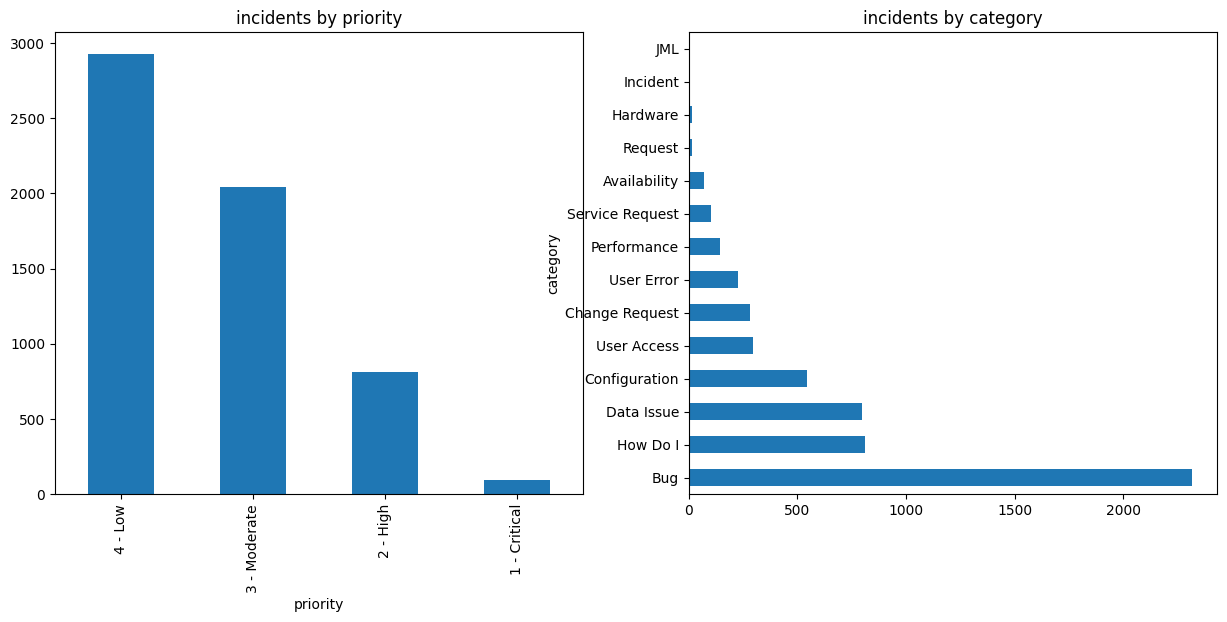

In [ ]:
#  incidents by priority and category
fig, axes = plt.subplots(1,2, figsize=(15,6))
incidents['priority'].value_counts().plot(kind='bar', title='incidents by priority', ax=axes[0] )
incidents['category'].value_counts().plot(kind='barh', title='incidents by category', ax=axes[1])
plt.show()

In [18]:
inc_min_date = incidents['opened'].min()
inc_max_date = incidents['opened'].max()

inc_min_date , inc_max_date

(Timestamp('2024-05-01 08:27:57'), Timestamp('2026-06-01 11:38:40'))

Text(0.5, 1.0, 'Total Incidents by calendar week')

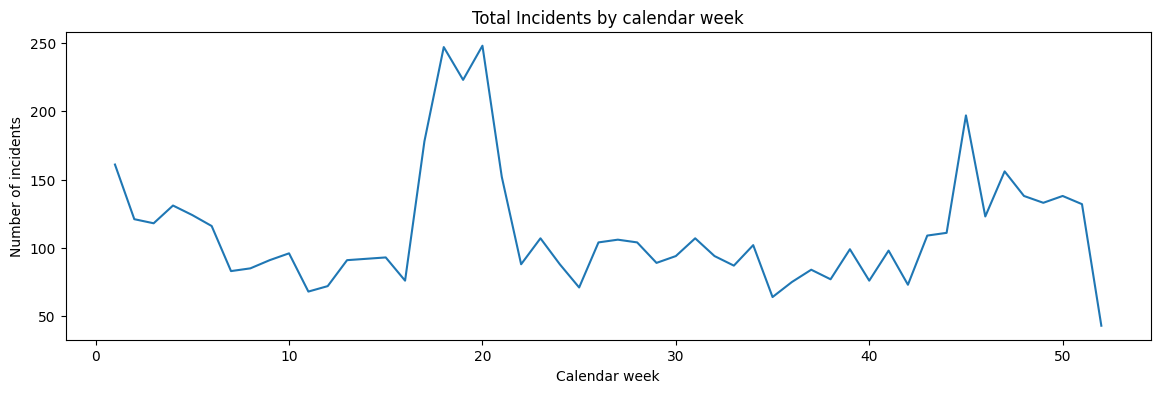

In [19]:
# incidents over time
incidents['cal_week'] = incidents['opened'].dt.strftime("%W").astype(int)
incidents['year'] = incidents['opened'].dt.year

weekly_total=incidents.groupby('cal_week').size().reindex(range(1,53), fill_value=0)

fig,ax=plt.subplots(figsize=(14,4))
ax.plot(weekly_total.index, weekly_total.values)
ax.set_ylabel('Number of incidents')
ax.set_xlabel('Calendar week')
ax.set_title("Total Incidents by calendar week")

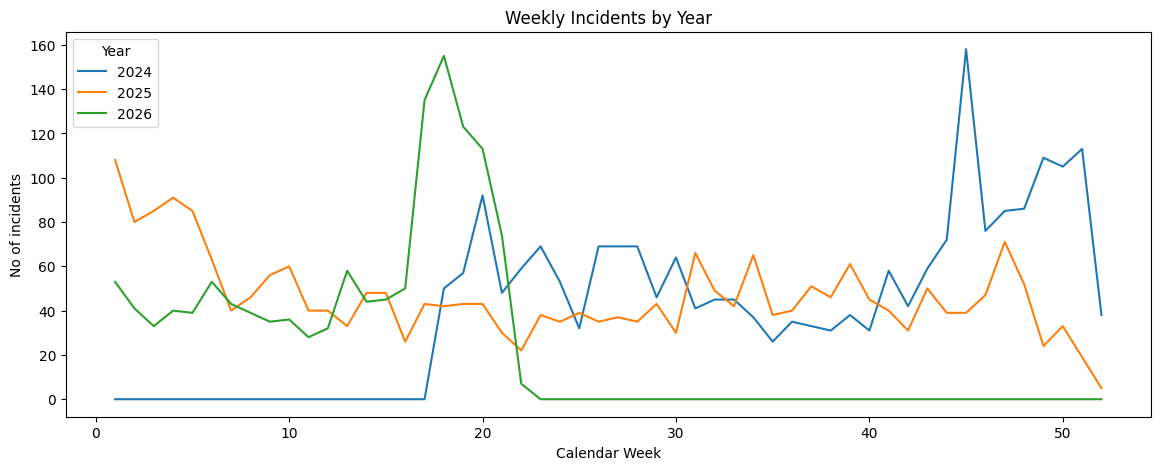

In [20]:
# weekly incidents by year
weekly_by_year = (incidents.groupby(['year','cal_week']).size().unstack(level=0, fill_value=0).reindex(range(1,53), fill_value=0))
fig, ax = plt.subplots(figsize=(14,5))
for year in weekly_by_year.columns:
    ax.plot(weekly_by_year.index, weekly_by_year[year], label=str(year))

ax.set_xlabel('Calendar Week')
ax.set_ylabel('No of incidents')
ax.set_title('Weekly Incidents by Year')
ax.legend(title='Year', loc='upper left')


In [21]:
weekly_by_year

year,2024,2025,2026
cal_week,,,
1,0,108,53
2,0,80,41
3,0,85,33
4,0,91,40
5,0,85,39
6,0,63,53
7,0,40,43
8,0,46,39
9,0,56,35


Data starts from May 2024

Huge spike in 2024  wk 45, 49-51

Huge spike in 2026 Wk 18-21

Investigate sudden spikes

In [22]:
inc_sorted = incidents[(incidents['cal_week'] == 1) & (incidents['year'] == 2025) ]
inc_sorted

,number,opened,closed,company,short_description,priority,category,assignment_group,assigned_to,business_service,cal_week,year
40,INC0030357,2025-01-07 12:04:20,2025-01-23 15:00:00,Network Rail,Close call email notifications no longer working,3 - Moderate,Configuration,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support,1,2025
170,INC0030326,2025-01-06 08:52:28,2025-01-16 15:00:00,KPMG NL - Shell,Job queues not working,2 - High,Bug,NAV and BC Agents,Sadri Salihu,Shell NL NAV Support,1,2025
348,INC0030434,2025-01-10 13:58:21,2025-06-13 10:00:00,ACCA,ACCA New Phase 1 - Testing Retries Payment,4 - Low,Bug,Azure ACCA Agents,Stephanie Zammit,ACCA Azure Integrations Support,1,2025
453,INC0030372,2025-01-07 17:12:23,2025-03-17 10:00:00,Marks Electrical Limited,SOA provision not working correctly,3 - Moderate,Change Request,FSCM Marks Agents,Uzair Mansuri,Marks FSCM Support,1,2025
503,INC0030327,2025-01-06 10:30:10,2025-03-17 10:00:00,Marks Electrical Limited,Orders - Mode of delivery should be the same,3 - Moderate,Bug,FSCM Marks Agents,Eric Vella,Marks FSCM Support,1,2025
...,...,...,...,...,...,...,...,...,...,...,...,...
5785,INC0030355,2025-01-07 11:03:48,2025-01-25 16:00:00,ACCA,DT - Tax Report 205,3 - Moderate,Bug,Data ACCA Agents,Moshood Owolabi,ACCA Data Support,1,2025
5788,INC0030425,2025-01-10 09:37:29,2025-02-21 10:00:00,ACCA,Member 1993122 -PC information displaying on DoM,4 - Low,Bug,Data ACCA Agents,Moshood Owolabi,ACCA Data Support,1,2025
5789,INC0030361,2025-01-07 14:50:16,2025-01-24 15:00:01,Stericycle,AZ-PROD-NEU-LA-Send-Notifications Failing,3 - Moderate,Configuration,Cloud Data Warehouse Stericycle Agents,VenkataKrishna Chunchu,Stericycle Cloud Data Warehouse,1,2025
5810,INC0030373,2025-01-07 17:56:30,2025-02-28 13:00:01,ACCA,Issues with regulatory reports: Register of St...,2 - High,Bug,Data ACCA Agents,Abhijeet Biswas,ACCA Data Support,1,2025


In [23]:
# incidents not logged in time card
inc_numbers = set(incidents['number'].dropna().unique())
tc_numbers = set(time_cards['number'].dropna().unique())
not_in_tc= inc_numbers - tc_numbers

inc_not_logged = incidents[incidents['number'].isin(not_in_tc)].copy()
print(inc_not_logged.shape)
inc_not_logged.head()




(1275, 12)


,number,opened,closed,company,short_description,priority,category,assignment_group,assigned_to,business_service,cal_week,year
4,INC0031948,2025-07-09 10:05:40,2025-09-27 12:00:00,Network Rail,Approved by DCP date on Investigations date de...,3 - Moderate,Bug,Power Platform Network Rail Support,Rajani Jamgamgunta,Network Rail Microsoft Platform Support,27,2025
7,INC0029489,2024-11-07 09:09:32,2024-12-12 09:00:01,Network Rail,Unable to close out Safety Events when Invest...,3 - Moderate,User Error,Power Platform Network Rail Support,Chandrakanth Kakumani,Network Rail Microsoft Platform Support,45,2024
9,INC0029787,2024-11-26 13:08:26,2025-01-23 15:00:00,Network Rail,Deployment of Super User role,4 - Low,Configuration,Power Platform Network Rail Support,Chandrakanth Kakumani,Network Rail Microsoft Platform Support,48,2024
15,INC0029854,2024-11-29 16:41:39,2025-01-23 15:00:00,Network Rail,Character length update for mentioned fields i...,4 - Low,Configuration,Power Platform Network Rail Support,Chandrakanth Kakumani,Network Rail Microsoft Platform Support,48,2024
22,INC0031881,2025-06-27 14:21:14,2025-08-11 10:00:00,Network Rail,Modified Flag Failing to Update - CHG0033259,2 - High,Configuration,Power Platform Network Rail Support,Chandrakanth Kakumani,Network Rail Microsoft Platform Support,25,2025


In [ ]:
# time logged but no incident record
no_incident = tc_numbers - inc_numbers

no_in_inc = time_cards[time_cards['number'].isin(no_incident)].copy()
print(len(no_incident))
no_in_inc.head()


2379


,date,number,short_description,company,business_service,project_id,technology,user,grade,specialisation,time_worked,week,cal_week,year
1,2024-05-09,GEN0010302,SDM / EM / EL,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Ivan Louis Carabott,B1,SDM,1.0,2024-05-06/2024-05-12,19,2024
3,2024-10-14,CHG0033079,Transition to Azure SynapseLink,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Jomer Majadas Sanosa,C1,FO Functional,1.5,2024-10-14/2024-10-20,42,2024
5,2024-10-28,CHG0033053,changes in the Austrian VAT return needed,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Korlapati Veera Raghava,D1,FO Functional,1.0,2024-10-28/2024-11-03,44,2024
7,2024-05-02,GEN0010302,SDM / EM / EL,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Ivan Louis Carabott,B1,SDM,1.0,2024-04-29/2024-05-05,18,2024
11,2024-07-24,GEN0010302,SDM / EM / EL,woom GmbH,woom FO Support,2914153,Dynamics 365 FO,Ivan Louis Carabott,B1,SDM,1.0,2024-07-22/2024-07-28,30,2024


In [25]:
# abt

abt=time_cards.merge(incidents, on='number', how='left', suffixes=['_tc','_inc'])
abt.shape

(87393, 25)

In [26]:
for col in ['technology', 'specialization','grade','priority','category']:
    if col in abt.columns:
        print(abt[col].isnull().mean()*100)

1.801059581431007
0.06178984586866225
59.69585664755759
61.31497946059753


In [27]:
summary = pd.DataFrame({
    "dtypes":abt.dtypes,
    "nulls": abt.isnull().sum(),
    "nulls_pct": (abt.isnull().sum()/len(abt) * 100).round(1),
    "unique": abt.nunique()
})

summary

,dtypes,nulls,nulls_pct,unique
date,datetime64[ns],0,0.0,653
number,object,300,0.3,6975
short_description_tc,object,300,0.3,6445
company_tc,object,300,0.3,46
business_service_tc,object,453,0.5,85
project_id,object,1574,1.8,53
technology,object,1574,1.8,9
user,object,0,0.0,158
grade,object,54,0.1,10
specialisation,object,13031,14.9,10


the 60% missing data must come from the 2379 raised tickets but time was not logged

In [33]:
abt.to_csv('../data/abt.csv')